Image Preprocessing for Inference (PyTorch)

Image Preprocessing Function

In [1]:
from PIL import Image
from torchvision import transforms

def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])
    return transform(image).unsqueeze(0)

This code preprocesses an image before passing it to a CNN model. It loads the image, converts it to RGB, resizes it to 224×224 pixels, converts it into a tensor, normalizes pixel values using ImageNet statistics, and adds a batch dimension so that the image can be used as input to a PyTorch CNN model.

| Line No. | Code                                            | Purpose                                       | Example                        | Explanation                                                                             |
| -------- | ----------------------------------------------- | --------------------------------------------- | ------------------------------ | --------------------------------------------------------------------------------------- |
| 1        | `from PIL import Image`                         | Import image processing library               | `Image.open("dog.jpg")`        | Used to open and manipulate image files.                                                |
| 2        | `from torchvision import transforms`            | Import PyTorch image transformation tools     | `transforms.Resize((224,224))` | Provides preprocessing operations such as resize, tensor conversion, and normalization. |
| 4        | `def preprocess_image(image_path):`             | Define a function                             | `preprocess_image("dog.jpg")`  | Creates a reusable function that takes an image path as input.                          |
| 5        | `image = Image.open(image_path).convert("RGB")` | Open image and convert to RGB                 | `Image.open("dog.jpg")`        | Loads the image and ensures it has 3 color channels (Red, Green, Blue).                 |
| 6        | `transform = transforms.Compose([`              | Create preprocessing pipeline                 | Multiple transforms combined   | Combines several preprocessing steps into one sequence.                                 |
| 7        | `transforms.Resize((224, 224))`                 | Resize image                                  | `500×300 → 224×224`            | CNN models require all images to have the same size.                                    |
| 8        | `transforms.ToTensor()`                         | Convert image to tensor                       | Image → Tensor                 | Converts image pixels into a PyTorch tensor and scales values to [0,1].                 |
| 9        | `transforms.Normalize([0.485,0.456,0.406],`     | Define mean values                            | RGB Mean Values                | Standard mean values from ImageNet dataset.                                             |
| 10       | `[0.229,0.224,0.225])`                          | Define standard deviation values              | RGB Std Values                 | Standard deviation values used for normalization.                                       |
| 11       | `])`                                            | End transformation pipeline                   | N/A                            | Closes the Compose() block.                                                             |
| 12       | `return transform(image).unsqueeze(0)`          | Apply transformations and add batch dimension | `[3,224,224] → [1,3,224,224]`  | Processes the image and adds a batch dimension required by CNN models.                  |


Transformation Flow Table
| Step | Input         | Operation    | Output               |
| ---- | ------------- | ------------ | -------------------- |
| 1    | `dog.jpg`     | Open Image   | PIL Image            |
| 2    | PIL Image     | Convert RGB  | RGB Image            |
| 3    | RGB Image     | Resize       | 224×224 Image        |
| 4    | 224×224 Image | ToTensor()   | Tensor `[3,224,224]` |
| 5    | Tensor        | Normalize    | Normalized Tensor    |
| 6    | `[3,224,224]` | unsqueeze(0) | `[1,3,224,224]`      |


Output Shape Explanation
| Shape           | Meaning                             |
| --------------- | ----------------------------------- |
| `[3,224,224]`   | Channels, Height, Width             |
| `[1,3,224,224]` | Batch Size, Channels, Height, Width |
| `1`             | Number of Images (Batch Size)       |
| `3`             | RGB Channels                        |
| `224`           | Image Height                        |
| `224`           | Image Width                         |


| Question                              | Answer                                                             |
| ------------------------------------- | ------------------------------------------------------------------ |
| Why use `Image.open()`?               | To load the image from disk.                                       |
| Why convert to RGB?                   | CNN models expect 3-channel RGB images.                            |
| Why resize to 224×224?                | Most pretrained CNN models use 224×224 input size.                 |
| Why use `ToTensor()`?                 | Converts image into PyTorch tensor format.                         |
| Why normalize the image?              | Improves model performance and training stability.                 |
| Why use ImageNet mean and std values? | Pretrained models were trained using these values.                 |
| Why use `unsqueeze(0)`?               | Adds batch dimension required by CNN models.                       |
| What is the final output shape?       | `torch.Size([1, 3, 224, 224])`                                     |
| Why is batch dimension needed?        | PyTorch models expect input as `[Batch, Channels, Height, Width]`. |


In [3]:
image_tensor = preprocess_image("dog.png")

print(image_tensor.shape)

torch.Size([1, 3, 224, 224])


To See Original Image Size

In [4]:
from PIL import Image

img = Image.open("dog.png")
print(img.size)

(267, 175)


To See Tensor Values

In [5]:
image_tensor = preprocess_image("dog.png")

print(image_tensor)

tensor([[[[-0.3541, -0.2342, -0.1828,  ..., -1.0733, -1.0733, -1.0904],
          [-0.3369, -0.2171, -0.1657,  ..., -1.0562, -1.0562, -1.0733],
          [-0.3198, -0.1999, -0.1657,  ..., -1.0390, -1.0562, -1.0733],
          ...,
          [-0.8507, -0.8507, -0.8507,  ..., -0.6452, -0.6452, -0.3712],
          [-0.8507, -0.8678, -0.8507,  ..., -0.6452, -0.5938,  0.2282],
          [-0.8678, -0.8849, -0.8678,  ..., -0.6452, -0.5082,  0.9988]],

         [[-0.0399,  0.0826,  0.1352,  ..., -1.0903, -1.0903, -1.1078],
          [-0.0049,  0.1001,  0.1527,  ..., -1.0553, -1.0728, -1.0903],
          [ 0.0126,  0.1352,  0.1702,  ..., -1.0203, -1.0378, -1.0553],
          ...,
          [-0.5126, -0.4776, -0.4601,  ..., -0.3025, -0.2850, -0.0224],
          [-0.5126, -0.4776, -0.4601,  ..., -0.3025, -0.2325,  0.5203],
          [-0.5301, -0.4951, -0.4776,  ..., -0.3025, -0.1450,  1.2206]],

         [[-1.1247, -1.0376, -1.0027,  ..., -1.4559, -1.4559, -1.4733],
          [-1.1247, -1.0376, -

To Display the Dog Image

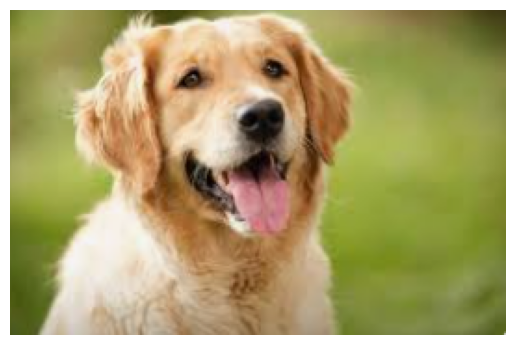

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("dog.png")

plt.imshow(img)
plt.axis("off")
plt.show()

Complete Test Code

In [7]:
image_tensor = preprocess_image("dog.png")

print("Tensor Shape:", image_tensor.shape)
print("Tensor Type:", type(image_tensor))

Tensor Shape: torch.Size([1, 3, 224, 224])
Tensor Type: <class 'torch.Tensor'>


Load a Pretrained CNN Model

Purpose:

Loads a pretrained ResNet18 CNN model.
model.eval() sets the model to prediction mode.

-----


In [8]:
import torch
import torchvision.models as models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model.eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 79.5MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

This model was trained on ImageNet (1000 classes).
========



Predict the Image

In [9]:
input_image = preprocess_image("dog.png")

with torch.no_grad():
    output = model(input_image)
    predicted_class = output.argmax(1).item()

print("Predicted Class Index:", predicted_class)

Predicted Class Index: 207


Get Class Result

In [10]:
with torch.no_grad():
    output = model(input_image)

probabilities = torch.nn.functional.softmax(output[0], dim=0)

top5_prob, top5_catid = torch.topk(probabilities, 5)

print(top5_catid)

tensor([207, 175, 216, 167, 215])


The top 5 predicted classes are:

207,
175,
216,
167,
215.

Show Probabilities

In [11]:
for i in range(5):
    print(
        f"Class ID: {top5_catid[i].item()}",
        f"Probability: {top5_prob[i].item():.4f}"
    )

Class ID: 207 Probability: 0.7987
Class ID: 175 Probability: 0.0384
Class ID: 216 Probability: 0.0352
Class ID: 167 Probability: 0.0206
Class ID: 215 Probability: 0.0187


What does 0.79 mean?
Class ID: 207 Probability: 0.79

means:

The model is 79% confident that the image belongs to Class 207.

| Rank | Class ID | Probability | Percentage |
| ---- | -------- | ----------- | ---------- |
| 1    | 207      | 0.7987      | 79.87%     |
| 2    | 175      | 0.0384      | 3.84%      |
| 3    | 216      | 0.0352      | 3.52%      |
| 4    | 167      | 0.0206      | 2.06%      |
| 5    | 215      | 0.0187      | 1.87%      |


Interpretation

| Class ID | Confidence                      |
| -------- | ------------------------------- |
| 207      | Very High Confidence (79.87%) ✅ |
| 175      | Low Confidence (3.84%)          |
| 216      | Low Confidence (3.52%)          |
| 167      | Very Low Confidence (2.06%)     |
| 215      | Very Low Confidence (1.87%)     |


The model is 79.87% confident that the image belongs to Class ID 207. Since this is the highest probability among all classes, Class ID 207 is selected as the final prediction using argmax().

Formula

Percentage is calculated as:

Percentage=Probability×100

Example:

0.7987 × 100 = 79.87%

To findout class name

In [12]:
weights = models.ResNet18_Weights.DEFAULT

categories = weights.meta["categories"]

print(categories[207])

golden retriever


Complete Code

In [13]:
weights = models.ResNet18_Weights.DEFAULT

categories = weights.meta["categories"]

print("Class ID:", predicted_class)
print("Class Name:", categories[predicted_class])

Class ID: 207
Class Name: golden retriever


the model you used is ResNet18 trained on ImageNet.

ImageNet doesn't have a single label called just "Dog".

Instead, it has many specific dog breeds such as:

| Class Name         |
| ------------------ |
| Golden Retriever   |
| Labrador Retriever |
| German Shepherd    |
| Beagle             |
| Bulldog            |
| Poodle             |

--------------------

So when my image is a dog, the model tries to identify the breed, not just the animal type.

| Step No. | Process          | Output                                   |
| -------- | ---------------- | ---------------------------------------- |
| 1        | Input Image      | Dog Image (`dog.png`)                    |
| 2        | Preprocessing    | Resize, Tensor Conversion, Normalization |
| 3        | CNN Model        | ResNet18                                 |
| 4        | Prediction       | Class ID = 207                           |
| 5        | Label Mapping    | ImageNet Category Mapping                |
| 6        | Final Result     | Golden Retriever                         |
| 7        | Confidence Score | 79.87%                                   |


Category ID put input and get Category name



In [15]:
import torch
import torchvision.models as models
import urllib.request

# 1. Load the model and weights
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.eval()

# 2. Download the ImageNet class labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
urllib.request.urlretrieve(url, "imagenet_classes.txt")

with open("imagenet_classes.txt", "r") as f:
    categories = [line.strip() for line in f.readlines()]

# 3. Find category for Class ID 207
class_id = 107
print(f"Category for ID {class_id}: {categories[class_id]}")

Category for ID 107: jellyfish


In [16]:
import torch
import torchvision.models as models
import urllib.request

# 1. Load the model and weights
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.eval()

# 2. Download the ImageNet class labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
urllib.request.urlretrieve(url, "imagenet_classes.txt")

with open("imagenet_classes.txt", "r") as f:
    categories = [line.strip() for line in f.readlines()]

# 3. Find category for Class ID 207
class_id = 850
print(f"Category for ID {class_id}: {categories[class_id]}")

Category for ID 850: teddy
